In [1]:
import numpy as np
import matplotlib.pyplot as plt
import keras


### Load Dataset

In [2]:
(train_images, train_labels), (test_images, test_labels) = keras.datasets.mnist.load_data()
train_images.shape, train_labels.shape, test_images.shape, test_labels.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [3]:
train_images[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

4


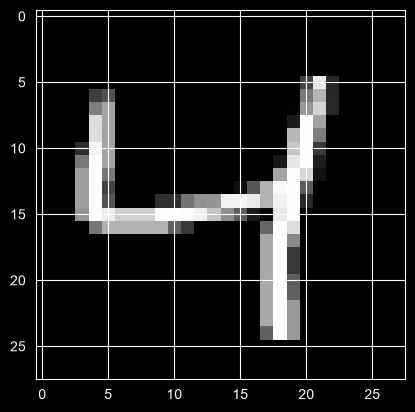

In [4]:
index = 2
print(train_labels[index])
plt.imshow(train_images[index], cmap="gray")
plt.show()

In [5]:
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255
test_images = test_images.reshape((10000, 28 * 28))
test_images = test_images.astype("float32") / 255

train_images.shape, test_images.shape

((60000, 784), (10000, 784))

### Add Noise

In [6]:
train_images_with_noise_channels = np.concatenate([train_images, np.random.random((len(train_images), 784))], axis=1)
train_images_with_noise_channels.shape

(60000, 1568)

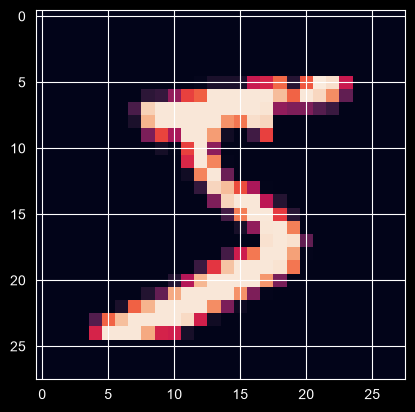

In [7]:
plt.imshow(train_images[0].reshape(28,28))

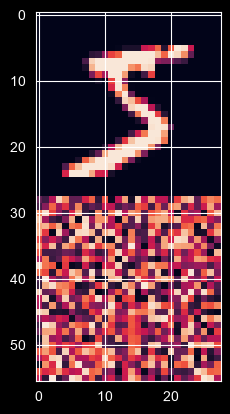

In [8]:
plt.imshow(train_images_with_noise_channels[0].reshape(56, 28))

In [9]:
train_images_with_zeros_channels = np.concatenate([train_images, np.zeros((len(train_images), 784))], axis=1)
train_images_with_zeros_channels.shape

(60000, 1568)

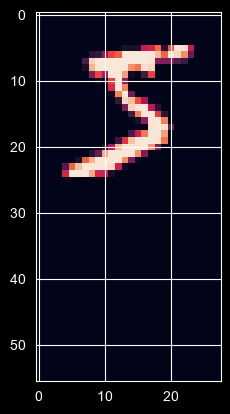

In [10]:
plt.imshow(train_images_with_zeros_channels[0].reshape(56, 28))

In [11]:
train_images_with_white_channels = np.concatenate([train_images, np.ones((len(train_images), 784))], axis=1)
train_images_with_white_channels.shape

(60000, 1568)

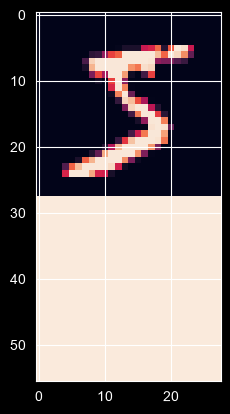

In [12]:
plt.imshow(train_images_with_white_channels[0].reshape(56, 28))

### Model

In [13]:
def get_model():
    model = keras.Sequential(
        [
            keras.layers.Dense(512, activation="relu"),
            keras.layers.Dense(10, activation="softmax"),
        ]
    )
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

### Training

In [14]:
model_noise = get_model()
history_noise = model_noise.fit(
    train_images_with_noise_channels,
    train_labels,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.8669 - loss: 0.4411 - val_accuracy: 0.9224 - val_loss: 0.2711
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9321 - loss: 0.2283 - val_accuracy: 0.9427 - val_loss: 0.2013
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9531 - loss: 0.1567 - val_accuracy: 0.9517 - val_loss: 0.1624
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9679 - loss: 0.1105 - val_accuracy: 0.9524 - val_loss: 0.1598
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9754 - loss: 0.0823 - val_accuracy: 0.9556 - val_loss: 0.1517
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9833 - loss: 0.0569 - val_accuracy: 0.9595 - val_loss: 0.1385
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9882 - loss: 0.0418 - val_accuracy: 0.9572 - val_loss: 0.1474
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9933 - loss: 0.0268 - val_accuracy: 0.

In [15]:
model_zeros = get_model()
history_zeros = model_zeros.fit(
    train_images_with_zeros_channels,
    train_labels,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9129 - loss: 0.3015 - val_accuracy: 0.9564 - val_loss: 0.1551
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9634 - loss: 0.1240 - val_accuracy: 0.9668 - val_loss: 0.1125
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9762 - loss: 0.0810 - val_accuracy: 0.9737 - val_loss: 0.0923
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9832 - loss: 0.0577 - val_accuracy: 0.9743 - val_loss: 0.0857
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9874 - loss: 0.0431 - val_accuracy: 0.9758 - val_loss: 0.0792
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9909 - loss: 0.0321 - val_accuracy: 0.9762 - val_loss: 0.0769
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9933 - loss: 0.0252 - val_accuracy: 0.9779 - val_loss: 0.0747
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9955 - loss: 0.0184 - val_accuracy: 0.

In [16]:
model_white = get_model()
history_white = model_white.fit(
    train_images_with_white_channels,
    train_labels,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8246 - loss: 0.6119 - val_accuracy: 0.9043 - val_loss: 0.3297
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9072 - loss: 0.3140 - val_accuracy: 0.9227 - val_loss: 0.2649
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9197 - loss: 0.2706 - val_accuracy: 0.9271 - val_loss: 0.2455
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9320 - loss: 0.2261 - val_accuracy: 0.9452 - val_loss: 0.1986
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9435 - loss: 0.1887 - val_accuracy: 0.9480 - val_loss: 0.1805
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9530 - loss: 0.1606 - val_accuracy: 0.9496 - val_loss: 0.1644
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9566 - loss: 0.1433 - val_accuracy: 0.9521 - val_loss: 0.1587
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9615 - loss: 0.1286 - val_accuracy: 0

In [18]:
model_normal = get_model()
history_normal = model_normal.fit(
    train_images,
    train_labels,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9161 - loss: 0.2956 - val_accuracy: 0.9560 - val_loss: 0.1591
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9647 - loss: 0.1228 - val_accuracy: 0.9654 - val_loss: 0.1192
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9772 - loss: 0.0801 - val_accuracy: 0.9709 - val_loss: 0.0954
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9839 - loss: 0.0564 - val_accuracy: 0.9747 - val_loss: 0.0817
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9881 - loss: 0.0416 - val_accuracy: 0.9779 - val_loss: 0.0755
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9921 - loss: 0.0297 - val_accuracy: 0.9768 - val_loss: 0.0740
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9949 - loss: 0.0219 - val_accuracy: 0.9765 - val_loss: 0.0778
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9960 - loss: 0.0167 - val_accuracy: 0.

### Compare

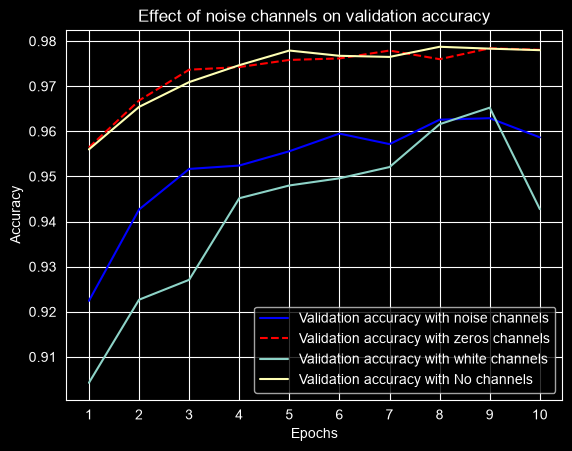

In [19]:
val_acc_noise = history_noise.history["val_accuracy"]
val_acc_zeros = history_zeros.history["val_accuracy"]
val_acc_white = history_white.history["val_accuracy"]
val_acc_normal = history_normal.history["val_accuracy"]
epochs = range(1, 11)
plt.plot(epochs,val_acc_noise,"b-",label="Validation accuracy with noise channels",)
plt.plot(epochs,val_acc_zeros, "r--", label="Validation accuracy with zeros channels")
plt.plot(epochs,val_acc_white, label="Validation accuracy with white channels")
plt.plot(epochs,val_acc_normal, label="Validation accuracy with No channels")

plt.title("Effect of noise channels on validation accuracy")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Accuracy")
plt.legend()
plt.show()
